# Homework 2 Solutions

**Financial Data Science II, Fall 2020**

## Question 1

The code below includes contributions from several students' submissions, along with some of my own code and my comments.

In [82]:
import yfinance as yf
import numpy as np
from statsmodels.graphics.gofplots import qqplot
import scipy.stats.distributions as spdists
import matplotlib.pyplot as plt
from scipy.stats import t

Read in the data, and then create "weekly" and "monthly" versions. Note that it is fine (and a good idea) to try symbols other than K.

In [83]:
Kdat = yf.download("K", start="2010-01-01",
   end="2018-12-31")
ldrK = np.log(Kdat['Adj Close']).diff()[1:]

# Weekly Data
Kweek = Kdat['Adj Close'][list(range(0,len(ldrK),5))]
ldrKweek = np.log(Kweek).diff()[1:]

# Monthly Data
Kmonth = Kdat['Adj Close'][list(range(0,len(ldrK),21))]
ldrKmonth = np.log(Kmonth).diff()[1:]

[*********************100%***********************]  1 of 1 downloaded


Consider the weekly data first. The normal probability plot of the log returns, and a comparison between the best fitting normal density and the kernel density estimate, are shown below.

Based on these, it is clear that the normal distribution is a better fit to weekly returns than it was to daily returns (using results that we saw in lecture). There may be a slight problem in the lower left tail, but it's difficult to say that is more than a possible artifact in this sample.

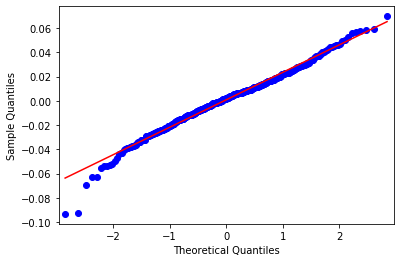

In [60]:
qqplot(ldrKweek,line="s")
plt.show()

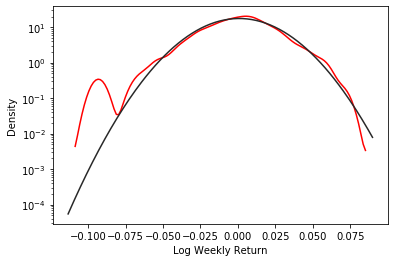

In [61]:
import seaborn as sns
from scipy.stats import norm

ax = sns.distplot(ldrKweek, hist=False,
   kde_kws={"bw": "silverman"}, 
   color="red", fit=norm)
plt.xlabel("Log Weekly Return")
plt.ylabel("Density")
plt.yscale("log")
plt.show()

Are there simple, known distributions that are better choices than the normal? We can compare the values of AIC over the candidates considered in lecture. First we need to load up the needed functions.

In [62]:
from scipy.stats import gennorm
import numdifftools as nd


def dSkewTb(x, V, k, n, CapLam, mu=0, log=False):
    
    from scipy.special import beta, betaln
    
# Apply the shift
    x = x - mu
    
# Lower case lambda as a function of capital lambda

    def LittleLam(CapLam):
        return(2.0/(1+np.exp(-CapLam)) - 1.0)


# This returns log of S() evaluated at _capital lambda_.
# See Equation (4) in Theo for S() evaluated at little lambda.

    def logSofLambda(k,n,CapLam):
        return(0.5*np.log(1+(3*(LittleLam(CapLam))**2) - 
         (4*(LittleLam(CapLam)*beta(2/k,(n-1)/k))**2) * 
         (1/beta(1/k,n/k)) * 
         (1/beta(3/k, ((n-2)/k)))))


# Log of C. See Equation (2) in Theo. Note that this is in
# terms of capital lambda, instead of lower case lambda.

    def logC(V,k,n,CapLam):
        return(np.log(0.5) + np.log(k) - 1.5*betaln(1/k,n/k) + 
        0.5*betaln(3/k, (n-2)/k) +
        logSofLambda(k,n,CapLam) - V/2)


# theta as defined in Equation (3) in Theo.

    def theta(k, n, CapLam):
        return(np.exp((1/k)*np.log((k/(n-2))) + 0.5*betaln(1/k,n/k) - 
        0.5*betaln(3/k,(n-2)/k) - logSofLambda(k,n,CapLam)))


# Return either the log of the likelihood evaluated at all of the values in
# x, or return the likelihood. 

    if log:
        return(logC(V,k,n,CapLam) - ((n+1)/k) * 
          np.log(1 + (k/(n-2))*(theta(k,n,CapLam)**(-k)) *
          ((1 + np.sign(x)*LittleLam(CapLam))**(-k)) * (abs(x*np.exp(-V/2))**k)))
    else:
        return(np.exp(logC(V,k,n,CapLam) - ((n+1)/k) * 
        np.log(1 + (k/(n-2))*(theta(k,n,CapLam)**(-k)) *
        ((1 + np.sign(x)*LittleLam(CapLam))**(-k)) * (abs(x*np.exp(-V/2))**k))))
    



def dSkewT(x, k, n, lam, sigma2, mu=0, log=False):

    CapLam = np.log((lam+1)/(1-lam))

    V = np.log(sigma2)
    
    return(dSkewTb(x,V,k,n,CapLam,mu,log=log))

def FitSkewT(dat, allowshift=False):

    from scipy.optimize import minimize
    
    # The parameter order for dSkewTb is V, k, n, CapLam, mu
    
    if(allowshift):
        initpars = [np.log(np.var(dat)), 2, 15.0, 0, np.mean(dat)]

        def negloglike(par,dat):
            return((-1)*sum(dSkewTb(dat,par[0],par[1],par[2],par[3],par[4],log=True)))    
    else:
        initpars = np.array([np.log(np.var(dat)), 1.5, 15.0, 0])
        def negloglike(par,dat):
            return((-1)*sum(dSkewTb(dat,par[0],par[1],par[2],par[3],0,log=True)))
    
    mleout = minimize(negloglike, initpars, args=(dat),method="Nelder-Mead",
                     options={'maxfev':2000})
    
    
    # The parameter out order is k, n, lambda, sigma2, (mu)
    if(mleout.status == 0):
        parout = mleout.x.copy()
        parout[0] = mleout.x[1]
        parout[1] = mleout.x[2]
        parout[2] = 2/(1+np.exp(-mleout.x[3])) - 1
        parout[3] = np.exp(mleout.x[0])
        return parout
    return(mleout.status, mleout.message)

Fit the distributions.

In [68]:
normalfitweek = norm.fit(ldrKweek)
GEDfitweek = gennorm.fit(ldrKweek)
tfitweek = t.fit(ldrKweek)
skewTfitweek = FitSkewT(ldrKweek)
skewTshiftfitweek = FitSkewT(ldrKweek, allowshift=True)

The plots below suggest that the distributions with heavier tails may overcompensate a bit when fitting to the lower tail, and, as a result, do not fit as well to the upper tail.

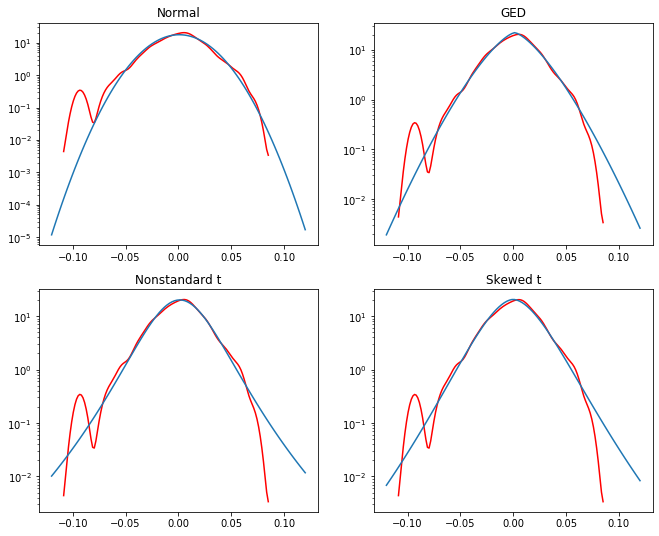

In [72]:
fig = plt.figure(figsize=(11, 9))

x = np.linspace(-0.12,0.12,100)

# Normal

ax = fig.add_subplot(2, 2, 1)
    
sns.distplot(ldrKweek, hist=False,
   kde_kws={"bw": "silverman"}, 
   color="red", ax=ax)

plt.plot(x,norm.pdf(x,normalfitweek[0],normalfitweek[1]))
plt.yscale("log")
plt.xlabel("")
plt.title("Normal")

# GED

ax = fig.add_subplot(2, 2, 2)
    
sns.distplot(ldrKweek, hist=False,
   kde_kws={"bw": "silverman"}, 
   color="red", ax=ax)

plt.plot(x,gennorm.pdf(x,GEDfitweek[0],GEDfitweek[1],GEDfitweek[2]))
plt.yscale("log")
plt.xlabel("")
plt.title("GED")

# Nonstandard t

ax = fig.add_subplot(2, 2, 3)
    
sns.distplot(ldrKweek, hist=False,
   kde_kws={"bw": "silverman"}, 
   color="red", ax=ax)

plt.plot(x,t.pdf(x,tfitweek[0],tfitweek[1],tfitweek[2]))
plt.yscale("log")
plt.xlabel("")
plt.title("Nonstandard t")

# Skewed t

ax = fig.add_subplot(2, 2, 4)
    
sns.distplot(ldrKweek, hist=False,
   kde_kws={"bw": "silverman"}, 
   color="red", ax=ax)

plt.plot(x,dSkewT(x,skewTfitweek[0],skewTfitweek[1],skewTfitweek[2],skewTfitweek[3]))
plt.yscale("log")
plt.xlabel("")
plt.title("Skewed t")

plt.show()

The values of AIC for each model are shown below. Among these five options, the nonstandard t distribution is the best choice. Hence, even though the normal fits better for weekly than it does for daily data, there is a better option among these simple alternatives.

In [74]:
print(-2*sum(norm.logpdf(ldrKweek,normalfitweek[0],
    normalfitweek[1]))+4)
print(-2*sum(gennorm.logpdf(ldrKweek,GEDfitweek[0],
    GEDfitweek[1],GEDfitweek[2]))+6)
print(-2*sum(t.logpdf(ldrKweek,tfitweek[0],tfitweek[1],
    tfitweek[2]))+6)
print(-2*sum(dSkewT(ldrKweek,skewTfitweek[0],skewTfitweek[1],
    skewTfitweek[2],skewTfitweek[3],log=True))+8)
print(-2*sum(dSkewT(ldrKweek,skewTshiftfitweek[0],
    skewTshiftfitweek[1],skewTshiftfitweek[2],
    skewTshiftfitweek[3],skewTshiftfitweek[4],log=True))+10)

-2137.2949868646433
-2150.081490116241
-2150.3425226831196
-2147.2083732018073
-2149.780338797831


Next we consider the monthly data. We first look at the normal probability plot, and compare the best fitting normal density with the kernel density estimate. Based on these comparisons, it appears clear that the fit of the normal distribution is even better for monthly data than it is for weekly.

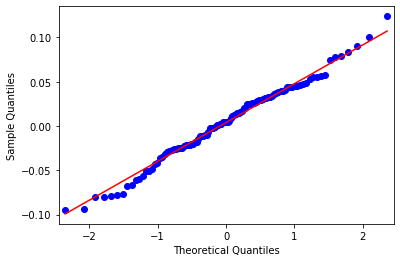

In [53]:
qqplot(ldrKmonth, line="s")
plt.show()

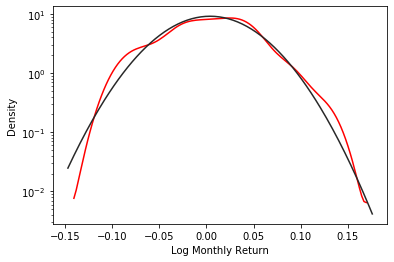

In [54]:
ax = sns.distplot(ldrKmonth, hist=False,
   kde_kws={"bw": "silverman"}, 
   color="red", fit=norm)
plt.xlabel("Log Monthly Return")
plt.ylabel("Density")
plt.yscale("log")
plt.show()

Let's again compare with our simple alternatives. Is the normal now preferred over them?

In [77]:
normalfitmonth = norm.fit(ldrKmonth)
GEDfitmonth = gennorm.fit(ldrKmonth)
tfitmonth = t.fit(ldrKmonth)
skewTfitmonth = FitSkewT(ldrKmonth)
skewTshiftfitmonth = FitSkewT(ldrKmonth, allowshift=True)

The plot below shows that all four appear to give roughly similar fits.

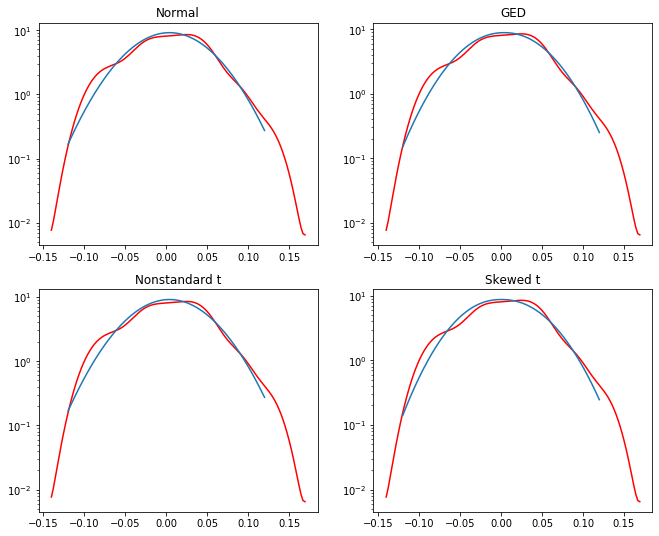

In [80]:
fig = plt.figure(figsize=(11, 9))

x = np.linspace(-0.12,0.12,100)

# Normal

ax = fig.add_subplot(2, 2, 1)
    
sns.distplot(ldrKmonth, hist=False,
   kde_kws={"bw": "silverman"}, 
   color="red", ax=ax)

plt.plot(x,norm.pdf(x,normalfitmonth[0],normalfitmonth[1]))
plt.yscale("log")
plt.xlabel("")
plt.title("Normal")

# GED

ax = fig.add_subplot(2, 2, 2)
    
sns.distplot(ldrKmonth, hist=False,
   kde_kws={"bw": "silverman"}, 
   color="red", ax=ax)

plt.plot(x,gennorm.pdf(x,GEDfitmonth[0],GEDfitmonth[1],GEDfitmonth[2]))
plt.yscale("log")
plt.xlabel("")
plt.title("GED")

# Nonstandard t

ax = fig.add_subplot(2, 2, 3)
    
sns.distplot(ldrKmonth, hist=False,
   kde_kws={"bw": "silverman"}, 
   color="red", ax=ax)

plt.plot(x,t.pdf(x,tfitmonth[0],tfitmonth[1],tfitmonth[2]))
plt.yscale("log")
plt.xlabel("")
plt.title("Nonstandard t")

# Skewed t

ax = fig.add_subplot(2, 2, 4)
    
sns.distplot(ldrKmonth, hist=False,
   kde_kws={"bw": "silverman"}, 
   color="red", ax=ax)

plt.plot(x,dSkewT(x,skewTfitmonth[0],skewTfitmonth[1],skewTfitmonth[2],skewTfitmonth[3]))
plt.yscale("log")
plt.xlabel("")
plt.title("Skewed t")

plt.show()

The comparison of the AIC values, shown below, supports the supposition we made from the plot, namely that the normal fits equally well to the others, and hence the extra complexity of the alternatives is not needed.

In [81]:
print(-2*sum(norm.logpdf(ldrKmonth,normalfitmonth[0],
    normalfitmonth[1]))+4)
print(-2*sum(gennorm.logpdf(ldrKmonth,GEDfitmonth[0],
    GEDfitmonth[1],GEDfitmonth[2]))+6)
print(-2*sum(t.logpdf(ldrKmonth,tfitmonth[0],tfitmonth[1],
    tfitmonth[2]))+6)
print(-2*sum(dSkewT(ldrKmonth,skewTfitmonth[0],skewTfitmonth[1],
    skewTfitmonth[2],skewTfitmonth[3],log=True))+8)
print(-2*sum(dSkewT(ldrKmonth,skewTshiftfitmonth[0],
    skewTshiftfitmonth[1],skewTshiftfitmonth[2],
    skewTshiftfitmonth[3],skewTshiftfitmonth[4],log=True))+10)

-361.62179008342383
-359.68159803494575
-359.6217875082426
-357.28299459052806
-356.0471225946001


**Comment:** This result is the central limit theorem at work. There is some time scale (spacing) of the prices such that the log return at that time scale is (roughly) independent. For the sake of argument, let's imagine that time scale is two hours. That would mean that daily, weekly, and monthly log returns are the sum of approximately 3, 15, and 60 independent observations, respectively. When viewed this way, it's not surprising that when we get to monthly data the CLT gives us a more normal shape, and with daily and weekly data it's not as good of an approximation.

## Question 2

In [4]:
import yfinance as yf
import numpy as np
Kdat = yf.download("K", start="2010-01-01",
   end="2018-12-31")
ldrK = np.log(Kdat['Adj Close']).diff()[1:]

[*********************100%***********************]  1 of 1 downloaded


In [5]:
def dSkewTb(x, V, k, n, CapLam, mu=0, log=False):
    
    from scipy.special import beta, betaln
    
# Apply the shift
    x = x - mu
    
# Lower case lambda as a function of capital lambda

    def LittleLam(CapLam):
        return(2.0/(1+np.exp(-CapLam)) - 1.0)


# This returns log of S() evaluated at _capital lambda_.
# See Equation (4) in Theo for S() evaluated at little lambda.

    def logSofLambda(k,n,CapLam):
        return(0.5*np.log(1+(3*(LittleLam(CapLam))**2) - 
         (4*(LittleLam(CapLam)*beta(2/k,(n-1)/k))**2) * 
         (1/beta(1/k,n/k)) * 
         (1/beta(3/k, ((n-2)/k)))))


# Log of C. See Equation (2) in Theo. Note that this is in
# terms of capital lambda, instead of lower case lambda.

    def logC(V,k,n,CapLam):
        return(np.log(0.5) + np.log(k) - 1.5*betaln(1/k,n/k) + 
        0.5*betaln(3/k, (n-2)/k) +
        logSofLambda(k,n,CapLam) - V/2)


# theta as defined in Equation (3) in Theo.

    def theta(k, n, CapLam):
        return(np.exp((1/k)*np.log((k/(n-2))) + 0.5*betaln(1/k,n/k) - 
        0.5*betaln(3/k,(n-2)/k) - logSofLambda(k,n,CapLam)))


# Return either the log of the likelihood evaluated at all of the values in
# x, or return the likelihood. 

    if log:
        return(logC(V,k,n,CapLam) - ((n+1)/k) * 
          np.log(1 + (k/(n-2))*(theta(k,n,CapLam)**(-k)) *
          ((1 + np.sign(x)*LittleLam(CapLam))**(-k)) * (abs(x*np.exp(-V/2))**k)))
    else:
        return(np.exp(logC(V,k,n,CapLam) - ((n+1)/k) * 
        np.log(1 + (k/(n-2))*(theta(k,n,CapLam)**(-k)) *
        ((1 + np.sign(x)*LittleLam(CapLam))**(-k)) * (abs(x*np.exp(-V/2))**k))))
    



def dSkewT(x, k, n, lam, sigma2, mu=0, log=False):

    CapLam = np.log((lam+1)/(1-lam))

    V = np.log(sigma2)
    
    return(dSkewTb(x,V,k,n,CapLam,mu,log=log))

In [6]:
import numdifftools as nd
import pandas as pd

def FitSkewT(dat, allowshift=False):

    from scipy.optimize import minimize
    
    # The parameter order for dSkewTb is V, k, n, CapLam, mu
    
    if(allowshift):
        initpars = [np.log(np.var(dat)), 2, 15.0, 0, np.mean(dat)]

        def negloglike(par,dat):
            return((-1)*sum(dSkewTb(dat,par[0],par[1],par[2],par[3],par[4],log=True)))    
    else:
        initpars = np.array([np.log(np.var(dat)), 1.5, 15.0, 0])
        def negloglike(par,dat):
            return((-1)*sum(dSkewTb(dat,par[0],par[1],par[2],par[3],0,log=True)))
    
    mleout = minimize(negloglike, initpars, args=(dat),method="Nelder-Mead",
                     options={'maxfev':2000})
    
    hessfunc = nd.Hessian(negloglike,step=0.1)
    ninfomatrix = hessfunc(mleout.x, dat) 
    mlevar = np.linalg.inv(ninfomatrix)
    
    if (allowshift):
        df = pd.DataFrame(mlevar, index = ['V', 'k', 'n', 'CapLam', 'mu'],
                              columns = ['V', 'k', 'n', 'CapLam', 'mu'])
        mlevar = np.array(df)
    
        G = np.zeros((5,5))
        G[0,0] = 1
        G[1,1] = 1
        G[2,2] = (2.0*(1+np.exp(-mleout.x[3]))**(-2))*np.exp(-mleout.x[3])
        G[3,3] = np.exp(mleout.x[0])
        G[4,4] = 1
    
        paroutvar = np.matmul(np.matmul(G, mlevar), G.T)

    else:
        df = pd.DataFrame(mlevar, index = ['V', 'k', 'n', 'CapLam'],
                                columns = ['V', 'k', 'n', 'CapLam'])

        mlevar = np.array(df)
    
        G = np.zeros((4,4))
        G[0,0] = 1
        G[1,1] = 1
        G[2,2] = (2.0*(1+np.exp(-mleout.x[3]))**(-2))*np.exp(-mleout.x[3])
        G[3,3] = np.exp(mleout.x[0])
    
        paroutvar = np.matmul(np.matmul(G, mlevar), G.T)
    
    # The parameter out order is k, n, lambda, sigma2, (mu)
    if(mleout.status == 0):
        parout = mleout.x.copy()
        parout[0] = mleout.x[1]
        parout[1] = mleout.x[2]
        parout[2] = 2/(1+np.exp(-mleout.x[3])) - 1
        parout[3] = np.exp(mleout.x[0])
        return parout, paroutvar
    
    return(mleout.status, mleout.message)

In [7]:
FitSkewT(ldrK, allowshift=True)

(array([ 1.75877143e+00,  3.78317473e+00, -4.05190316e-02,  1.20964255e-04,
         8.02689667e-04]),
 array([[ 6.17358204e-03,  3.74597242e-03, -1.45556092e-02,
         -9.49700669e-08,  1.64135481e-05],
        [ 3.74597242e-03,  2.40087945e-02, -3.14301673e-02,
         -1.96382038e-07,  3.62944772e-05],
        [-1.45556092e-02, -3.14301673e-02,  6.53418617e-02,
          4.31155850e-07, -7.89791104e-05],
        [-9.49700669e-08, -1.96382038e-07,  4.31155850e-07,
         -1.29872389e-11,  4.67444587e-09],
        [ 1.64135481e-05,  3.62944772e-05, -7.89791104e-05,
          4.67444587e-09, -8.48790715e-07]]))

In [8]:
FitSkewT(ldrK, allowshift=False)

(array([1.81732171e+00, 3.63682709e+00, 1.56181184e-02, 1.22364211e-04]),
 array([[ 6.98484843e-03,  4.78781440e-03, -1.53036122e-02,
          1.18913761e-08],
        [ 4.78781440e-03,  2.65730035e-02, -3.11162992e-02,
          3.18196864e-09],
        [-1.53036122e-02, -3.11162992e-02,  5.78450448e-02,
         -3.00242267e-08],
        [ 1.18913761e-08,  3.18196864e-09, -3.00242267e-08,
          1.30306057e-11]]))

In [10]:
np.random.seed(0)
from scipy.stats import norm

x = norm.rvs(size=1000)

print(FitSkewT(x, allowshift=True))
print(FitSkewT(x, allowshift=False))

(array([ 1.95886478e+00,  1.30521461e+06,  3.05299814e-02,  9.74238473e-01,
       -9.32487177e-02]), array([[ 2.03737921e-03, -7.05186353e-05, -3.77536787e-06,
         1.16766159e-04, -9.37788087e-05],
       [-7.05186353e-05,  1.98112189e-02,  8.52108024e-04,
        -5.79562356e-04,  5.06801723e-04],
       [-3.77536787e-06,  8.52108024e-04,  1.52956012e+03,
        -2.73638945e-05,  2.40070724e-05],
       [ 1.16766159e-04, -5.79562356e-04, -2.73638945e-05,
         7.91598776e-03, -6.35905299e-03],
       [-9.37788087e-05,  5.06801723e-04,  2.40070724e-05,
        -6.35905299e-03,  6.08074349e-03]]))
(array([ 1.97240501e+00,  1.74261449e+06, -1.97535732e-02,  9.75326035e-01]), array([[ 2.02156110e-03, -3.20712639e-05,  5.34144365e-05,
        -1.22757925e-05],
       [-3.20712639e-05,  2.01571878e-02, -2.77284594e-03,
         2.30104468e-04],
       [ 5.34144365e-05, -2.77284594e-03,  1.78961101e+03,
        -3.17819944e-05],
       [-1.22757925e-05,  2.30104468e-04, -3.17819944

## Question 3

Reconsider the Kellog's daily log return data:

In [376]:
import yfinance as yf
import numpy as np
Kdat = yf.download("K", start="2010-01-01",
   end="2018-12-31")
ldrK = np.log(Kdat['Adj Close']).diff()[1:]

[*********************100%***********************]  1 of 1 downloaded


In [377]:
from scipy.stats import norm
import numdifftools as nd
from scipy.stats import t
import statsmodels.api as sm
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

**(a)**

**1. Using the sample proportion**

In [378]:
cutuse = -0.025

large_drop = ldrK < cutuse
phat1 = sum(large_drop) / len(ldrK)
print("Using the sample proportion, p is estimated to be", phat1)

Using the sample proportion, p is estimated to be 0.016799292661361626


We can think of $X_1, X_2, ..., X_n$ as i.i.d. Bernoulli(p) with p = $\mathbb{P}(X_i < -0.025)$.

$Var(p) = Var(\frac{1}{n}(X_1 + ... + X_n))  = \frac{1}{n^2}[Var(X_1) + ... + Var(X_n)] = \frac{Var(X_i)}{n} = \frac{p(1-p)}{n}$ since $X_i$'s are i.i.d.

$Var(\hat p) = \frac{\hat p(1-\hat p)}{n}$, and thus $SE(\hat p) = \sqrt{\frac{\hat p(1-\hat p)}{n}}$

In [379]:
se1 = np.sqrt(phat1*(1-phat1)/len(ldrK))
print("The corresponding standard error is", se1)

The corresponding standard error is 0.002702217417012585


**2. Using the tail probability from a fitted normal distribution**

In [380]:
fit_norm = norm.fit(ldrK)
phat2 = norm.cdf(cutuse, fit_norm[0], fit_norm[1])
print("Using the tail probability from a fitted normal distribution, p is estimated to be", phat2)

Using the tail probability from a fitted normal distribution, p is estimated to be 0.010142465231274557


We can try using the Fisher information and the Delta method to get at this standard error.

In [381]:
def normcdf(x):
    return norm.cdf(cutuse, x[0], x[1])

gradient = nd.Gradient(normcdf,step=0.001)
G = gradient(fit_norm)

In [382]:
def negloglikelihood(pars):
    return (-1)*sum(norm.logpdf(ldrK, pars[0], pars[1]))

hessfunc = nd.Hessian(negloglikelihood,step=0.001)
ninfomatrix = hessfunc(fit_norm)

mlevar = np.linalg.inv(ninfomatrix)

se2 = np.sqrt(np.matmul(np.matmul(G, mlevar), G.T))

print("The corresponding standard error is", se2)

The corresponding standard error is 0.0010594110976333837


We could also use the bootstrap to approximate the standard error. Consider the code below.

In [383]:
def normtp(x):
    fit_norm = norm.fit(x)
    return norm.cdf(cutuse, fit_norm[0], fit_norm[1])

def phat2bootstrap(B = 1000):
    phat2boot = np.zeros(B)
    
    from tqdm.notebook import tnrange
    
    for b in tnrange(B):
        bootx = np.random.choice(ldrK, len(ldrK), replace = True)
        phat2boot[b] = normtp(bootx)
    
    se2 = np.std(phat2boot)
    
    print("The standard error using the bootstrap is", se2)

What is the source of the discrepancy here? The problem is that the approach using the Fisher information is only valid when the model is correctly specified. The sample is clearly not drawn from the normal distribution, but we proceed through the calculation under the assumption that it is. Hence, the standard error of the estimators for the parameters is incorrect. 

If you run the bootstrap procedure to inspect the standard error on the estimator for the standard deviation, you will find that the Fisher information approach significantly underestimates its value. This is because there is much more probability out in the tails than the normal distribution expects, and hence more variability in the estimator for the standard deviation.

**3. Using the tail probability from a fitted t distribution**

In [395]:
fit_t = t.fit(ldrK,3)
phat3 = t.cdf(cutuse, fit_t[0], fit_t[1], fit_t[2])
print("Using the tail probability from a fitted t distribution, p is estimated to be", phat3)

Using the tail probability from a fitted t distribution, p is estimated to be 0.015941803010434446


Again, we can try the Fisher information and Delta method.

In [396]:
def tcdf(x):
    return t.cdf(cutuse, x[0], x[1], x[2])

gradient = nd.Gradient(tcdf,step=0.001)
G = gradient(fit_t)

In [397]:
def negloglikelihood(pars):
    return (-1)*sum(t.logpdf(ldrK, pars[0], pars[1], pars[2]))

hessfunc = nd.Hessian(negloglikelihood,step=0.001)
ninfomatrix = hessfunc(fit_t)

mlevar = np.linalg.inv(ninfomatrix)

se3 = np.sqrt(np.matmul(np.matmul(G, mlevar), G.T))

print("The corresponding standard error is", se3)

The corresponding standard error is 0.0015502629036495724


Let's again compare with the bootstrap.

In [398]:
def ttp(x):
    fit_t = t.fit(x,3)
    return t.cdf(cutuse, fit_t[0], fit_t[1], fit_t[2])


def phat3bootstrap(B = 1000):
    phat3boot = np.zeros(B)
    
    from tqdm.notebook import tnrange
    
    for b in tnrange(B):
        bootx = np.random.choice(ldrK, len(ldrK), replace = True)
        phat3boot[b] = ttp(bootx)
    
    se3 = np.std(phat3boot)
    
    print("The standard error using the bootstrap is", se3)

In [399]:
phat3bootstrap()


The standard error using the bootstrap is 0.0014629523079630752


This time the bootstrap and the "analytical" approach agree. (We, of course, expect slight disagreement due to random variation in the bootstrap.)

When I did this initially, the bootstrap estimate of the standard error was much larger. Ultimately, I determined that the function `t.fit()` makes poor choice for the starting value for the degrees of freedom parameter when doing its numerical search for the MLE. (It uses 1 as the initial value.) By setting this equal to 3, performance improved.

**4. Using the tail probability from a fitted kernel density estimate**

In [25]:
def KDEtp(x):
    dens = sm.nonparametric.KDEUnivariate(x)
    dens.fit()
    dens.support = np.array(cutuse)
    
    return dens.cdf

In [401]:
def phat4bootstrap(B = 1000):
    phat4boot = np.zeros(B)
    
    from tqdm.notebook import tnrange
    
    for b in tnrange(B):
        bootx = np.random.choice(ldrK, len(ldrK), replace = True)
        phat4boot[b] = KDEtp(bootx)
    
    phat4 = np.mean(phat4boot)
    se4 = np.std(phat4boot)
    
    print("Using the tail probability from a fitted kernel density estimate, p is estimated to be", KDEtp(ldrK))
    print("The corresponding standard error is", se4)

In [402]:
phat4bootstrap(1000)


Using the tail probability from a fitted kernel density estimate, p is estimated to be [0.01718243]
The corresponding standard error is 0.0025736000976522575


**(b)**

We see above that the fit from the normal distribution has the smallest standard error when calculated using Fisher information, but it turns out that this was driven by an incorrect assumption, i.e., that the sample was drawn from a normal distribution.

Also, SE is only part of the story. We also need to be concerned about **bias** in the estimator. And we know that the normal distribution is a poor fit to this sample, especially in the tails, and hence the resulting tail probability estimate will also be quite biased.

Instead, we prefer an estimator that we know to come from a distribution which is a reasonable fit to the sample. The sample proportion is unbiased, but there is no smoothing taking place at all, and hence the variance is larger than it could be. The t distribution fit was shown to be a good choice, with less bias, and also achieves a smaller SE than does the sample proportion. The nonparametric smoothing approach can also be assumed to be (roughly) unbiased, but we observe that the SE is somewhat larger than the t fit. This is not surprising since there is a greater amount of smoothing with the t fit.

Overall, the fit from the t distribution seems to give the most reliable esimator for the tail probability.